In [1]:
import numpy as np
import torch
from tqdm import tqdm
from scipy.optimize import curve_fit
import sys
sys.path.append('../')
from tools import *
from genData import *
from plot import *
from model.unet import Attention_UNet

# Set random seeds for reproducibility
np.random.seed(1)
torch.manual_seed(1)

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA is not available. No GPU found.")

def compute_detection_statistic(images, method= 'mean'):
    images_np = np.abs(images)
    return np.mean(np.square(images_np.transpose(0, 2, 3, 1)), axis=(1, 2, 3))

# Configuration
det = 'H1L1'
f0 = 20
size = (512, 64)
Tsft = 14400
train_level = 32
batch_size = 8

# Model version
version = f'H1L1_a1b1_{f0}Hz_D{train_level}-{train_level}_T10_f512xTsft14400_ndata7000_noise7000_latent64_batch8_lr0.0001_512x64_MSELoss_dropout0'

# Load validation data (targets and masks)
filename = f'/scratch/kriles_root/kriles0/damoncht/unet_f/data/validation/{f0}Hz_H1L1_{size[0]}x{size[1]}_{Tsft}s_4c_traindata_n1000_idx4.npz'
val_data = np.load(filename, allow_pickle=True)
targets = val_data['clean_image']
masks = new_mask(normalize(targets))  # Assuming new_mask and normalize are defined in utils

# Load model
model = Attention_UNet(in_channels=4, out_channels=4, latent_channels=64, dropout_prob=0).to(device)
best_val_model = torch.load(f"../trained_model/{f0}Hz/best_pdet_model_mean_sq_{version}.pth", weights_only=False)
model.load_state_dict(best_val_model)

25-09-22 17:20:18.331 pyfstat INFO    : Running PyFstat version 2.1.0


/home/damoncht/.conda/envs/ml/lib/python3.9/site-packages/pyfstat/core.py:12: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


GPU Name: Tesla P40


<All keys matched successfully>

In [ ]:

# Initialize lists for depth and pdet
depth = []
pdet = []
max_train_levels = [5*i for i in range(1, 21)]  
# Compute pdet
noise_data = np.empty((1000,) + size + (4,))
for i in range(noise_data.shape[0]):
    noise_data[i] = simNoise(sqrtSn=1, Tsft=Tsft, size=size, ndet=2, norm=False)
noise_data = normalize(noise_data)
noise_loader = load_dataset(noise_data, batch_size=batch_size, shuffle=False)

noise_predictions = []
with torch.no_grad():
    for batch in tqdm(noise_loader, desc="Processing noise"):
        images = batch[0].to(device)
        outputs = model(images)
        noise_predictions.append(outputs.cpu().numpy())
noise_predictions = np.concatenate(noise_predictions, axis=0)
noise_stats = compute_detection_statistic(noise_predictions, method='mean_sq')

    
# Process each noise level one at a time
for Sn in max_train_levels:
    # Generate noise for current Sn
    noise = np.empty((targets.shape[0],) + size + (4,))
    for i in range(noise.shape[0]):
        noise[i] = simNoise(sqrtSn=Sn, Tsft=Tsft, size=size, ndet=2, norm=False)  # Assuming simNoise is defined
    data = normalize(noise + targets)
    data_loader = load_dataset(data, batch_size=batch_size, shuffle=False)

    # Compute predictions
    predictions = []
    with torch.no_grad():
        for images, in tqdm(data_loader, desc=f"Processing Sn={Sn}"):
            images = images.to(device)
            outputs = model(images)
            predictions.append(outputs.cpu().numpy())
    predictions = np.concatenate(predictions, axis=0)

    # Compute detection statistic
    stats = compute_detection_statistic(predictions, method='mean_sq')

    
    x_pfa = np.percentile(noise_stats, (1 - 0.71 / 100) * 100)
    mask = stats > x_pfa
    pdet_value = mask.sum() / mask.size

    # Store results
    depth.append(Sn)
    pdet.append(pdet_value)

# Convert to numpy arrays
depth = np.array(depth)
pdet = np.array(pdet)

In [ ]:
# Data from previous context (assuming depth and pdet are from the optimized code)
depth_mf = np.array([20.202557445466237, 29.819911193070148, 35.00972993958217, 
                     43.98243272753743, 55.55819765607939, 59.86577050930532, 
                     70.5983063596438, 79.96641836313785, 84.91922451653605, 
                     93.97578433989275, 100.0624074927814, 109.67219081357824])
pdet_mf = np.array([0.9968030411616241, 0.9972330414732185, 0.9664350481413393, 
                    0.8019879724550525, 0.5893621662044682, 0.5244757423737264, 
                    0.3989904340510392, 0.2883245567569252, 0.24539930826036832, 
                    0.16035272489327893, 0.11295921228928427, 0.05648583803321597])

            
# Create figure and axis
colors = plt.cm.tab10(np.linspace(0, 1, 10))  # Use tab10 colormap for distinct colors

fig, ax = plt.subplots(figsize=(10, 8))

# Plot Weave data as a line
#ax.plot(depth_mf[:-2], pdet_mf[:-2], color='k', label='Weave', lw=2)
sort_idx = np.argsort(depth)
depth_sorted = depth[sort_idx]
pdet_sorted = pdet[sort_idx]
p90 = 0.9
d90 = np.interp(p90, pdet_sorted[::-1], depth_sorted[::-1])  # Reverse to handle decreasing pdet

# Plot Attention UNet data with line and markers
ax.plot(depth, pdet, color=colors[0], linestyle='-', lw=2, marker='o', markersize=8, label='Attention UNet')

# Add horizontal and vertical lines at pdet = 0.9 and interpolated depth
ax.plot([0, d90], [p90, p90], color='red', linestyle='--', lw=1.5)
ax.plot([d90, d90], [-0.05, p90], color='red', linestyle='--', lw=1.5, 
        label=r'$\mathcal{D}^{90\%}=$' + f' {d90:.2f}')

# Axis labels and styling
ax.set_xlabel(r'$\mathcal{D}\; (\mathrm{Hz}^{-1/2})$')
ax.set_ylabel(r'$p_{\mathrm{det}}$')
ax.legend(fontsize=22, loc='upper right', markerscale=2, handlelength=2, handletextpad=0.5, bbox_to_anchor=(1, 0.8))
ax.grid(True, which='major', linestyle='dashed')
ax.set_xlim(0, 105)
ax.set_ylim(-0.05, 1.05)
ax.tick_params(axis='both', which='major', labelsize=22)
ax.minorticks_on()
ax.grid(True, which='minor', linestyle=':', alpha=0.3)

# Save figure
plt.tight_layout()

In [ ]:
max_train_levels = [40.2790, 29, 31]

depth_ex = []
pdet_ex = []
# Process each noise level one at a time
for Sn in max_train_levels:
    # Generate noise for current Sn
    noise = np.empty((targets.shape[0],) + size + (4,))
    for i in range(noise.shape[0]):
        noise[i] = simNoise(sqrtSn=Sn, Tsft=Tsft, size=size, ndet=2, norm=False)  # Assuming simNoise is defined
    data = normalize(noise + targets)
    data_loader = load_dataset(data, batch_size=batch_size, shuffle=False)

    # Compute predictions
    predictions = []
    with torch.no_grad():
        for images, in tqdm(data_loader, desc=f"Processing Sn={Sn}"):
            images = images.to(device)
            outputs = model(images)
            predictions.append(outputs.cpu().numpy())
    predictions = np.concatenate(predictions, axis=0)

    # Compute detection statistic
    stats = compute_detection_statistic(predictions, method='mean_sq')

    
    x_pfa = np.percentile(noise_stats, (1 - 0.71 / 100) * 100)
    mask = stats > x_pfa
    pdet_value = mask.sum() / mask.size

    # Store results
    depth_ex.append(Sn)
    pdet_ex.append(pdet_value)

# Convert to numpy arrays
depth_ex = np.array(depth_ex)
pdet_ex = np.array(pdet_ex)

In [ ]:
depth_ex, pdet_ex

In [ ]:
binomialError(pdet_ex, 1000)*100

In [ ]:
np.savez(f'./result/data/pdet_depth_{f0}Hz.npz', pdet=pdet_combined, depth=depth_combined)

In [8]:
from plot import *

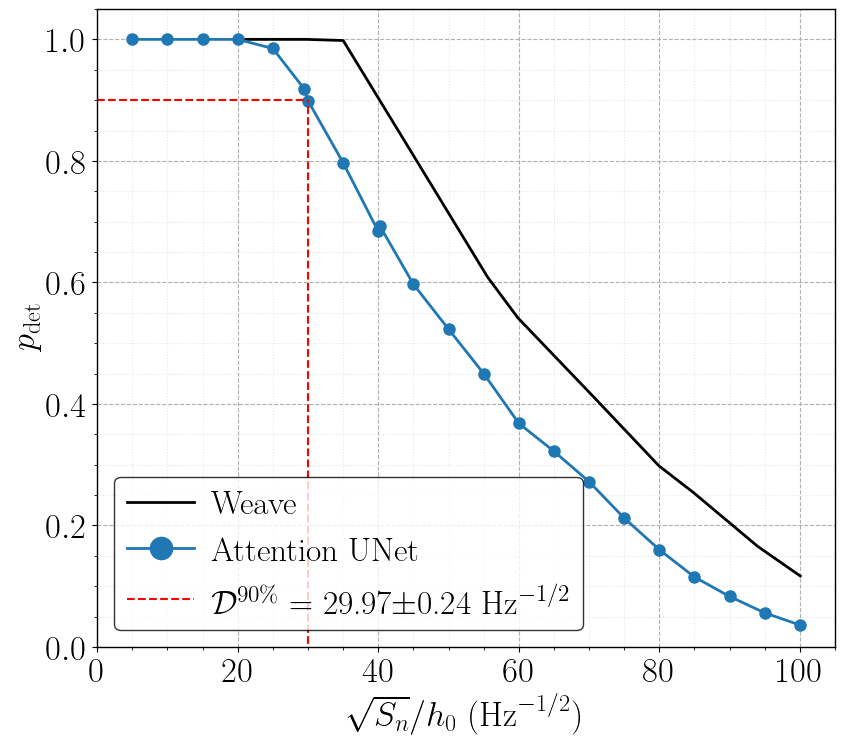

In [5]:
# Insert depth_ex and pdet_ex into depth and pdet to maintain ascending order
# Combine all points
# combined = np.vstack((np.column_stack((depth, pdet)), np.column_stack((depth_ex, pdet_ex))))
# # Sort by depth (first column)
# sorted_indices = np.argsort(combined[:, 0])
# depth_combined = combined[sorted_indices, 0]
# pdet_combined = combined[sorted_indices, 1]
p90 = 0.9

pdet_combined = np.load(f'../result/data/pdet_depth_{f0}Hz.npz')['pdet']
depth_combined = np.load(f'../result/data/pdet_depth_{f0}Hz.npz')['depth']

# Use only the first len(depth)-4 points from combined data (to match depth[:-4])
n_points = len(depth_combined)
depth_plot = depth_combined[:n_points]
pdet_plot = pdet_combined[:n_points]

# Interpolate depth at pdet = 0.9
# Sort by depth for interpolation (already sorted, but confirm)
sort_idx = np.argsort(depth_plot)
depth_sorted = depth_plot[sort_idx]
pdet_sorted = pdet_plot[sort_idx]

# Create figure and axis
fig, ax = plt.subplots(figsize=(9, 8))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Data from previous context (assuming depth and pdet are from the optimized code)
depth_mf = np.array([20.202557445466237, 29.819911193070148, 35.00972993958217, 
                     43.98243272753743, 55.55819765607939, 59.86577050930532, 
                     70.5983063596438, 79.96641836313785, 84.91922451653605, 
                     93.97578433989275, 100.0624074927814, 109.67219081357824])
pdet_mf = np.array([0.9968030411616241, 0.9972330414732185, 0.9664350481413393, 
                    0.8019879724550525, 0.5893621662044682, 0.5244757423737264, 
                    0.3989904340510392, 0.2883245567569252, 0.24539930826036832, 
                    0.16035272489327893, 0.11295921228928427, 0.05648583803321597])

pdet_mf *= (921600/864000)**0.5
pdet_mf[pdet_mf>1] = 1
ax.plot(depth_mf[:-1], pdet_mf[:-1], color='k', label='Weave', lw=2)



dpdet = binomialError(pdet_sorted, 1000)
# Compute interpolation and error
d90, d90_err = interpolation_error(0.9, depth_sorted, pdet_sorted, dpdet)

# Plot combined Attention UNet data with line and markers
ax.plot(depth_plot, pdet_plot, color=colors[0], linestyle='-', lw=2, marker='o', markersize=8, label='Attention UNet')

# Add horizontal and vertical lines at pdet = 0.9 and interpolated depth
ax.plot([0, d90], [p90, p90], color='red', linestyle='--', lw=1.5)
ax.plot([d90, d90], [-0.05, p90], color='red', linestyle='--', lw=1.5, 
        label=r'$\mathcal{D}^{90\%}=$' + f' {d90:.2f}'r'$\pm$'+ f'{d90_err:.2f}'+r'$\;\mathrm{Hz}^{-1/2}$')

# Axis labels and styling
ax.set_xlabel(r'$\sqrt{S_n}/h_0\; (\mathrm{Hz}^{-1/2})$', fontsize=25)
#ax.set_xlabel(r'$\mathcal{D}\; (\mathrm{Hz}^{-1/2})$', fontsize=25)
ax.set_ylabel(r'$p_{\mathrm{det}}$', fontsize=25)
ax.legend(fontsize=24, loc=3, markerscale=2, handlelength=2, handletextpad=0.5, edgecolor='k')
ax.grid(True, which='major', linestyle='dashed')
ax.set_xlim(0, 105)
ax.set_ylim(0, 1.05)
ax.tick_params(axis='both', which='major', labelsize=25)
ax.minorticks_on()
ax.grid(True, which='minor', linestyle=':', alpha=0.3)

# Save figure
plt.tight_layout()
plt.savefig('../result/plots/pdet_20Hz.pdf', dpi=300, bbox_inches='tight')

# Duty factor

In [ ]:
model.eval()

duty_factors = [1.0, 0.9, 0.8, 0.7, 0.6]  # Range of duty factors (1.0 = no gaps, 0.4 = 60% gaps)

# Initialize results storage
results = {df: {'depth': [], 'pdet': []} for df in duty_factors}

# Process each duty factor
for duty_factor in duty_factors:
    if duty_factor == 0.7:
        max_train_levels = [d for d in range(23, 27)]  
    elif duty_factor == 0.6:
        max_train_levels = [d for d in range(20, 24)]  
    elif duty_factor >= 0.8:
        max_train_levels = [d for d in range(27, 33)]  
        
    print(f"\nProcessing duty factor: {duty_factor}")
    num_zero_cols = int(size[1] * (1 - duty_factor))
    zero_cols = np.random.choice(size[1], size=num_zero_cols, replace=False)  # Randomly select columns
    
    # Compute noise statistics (no duty factor applied)
    noise_data = np.empty((1000,) + size + (4,))
    for i in range(noise_data.shape[0]):
        noise_data[i] = simNoise(sqrtSn=1, Tsft=Tsft, size=size, ndet=2, norm=False)

    noise_data = apply_duty_factor(noise_data, duty_factor, size, zero_cols)  # Apply duty factor
    noise_data = normalize(noise_data)
    noise_loader = load_dataset(noise_data, batch_size=batch_size, shuffle=False)
        
    noise_predictions = []
    with torch.no_grad():
        for batch in tqdm(noise_loader, desc="Processing noise"):
            images = batch[0].to(device)
            outputs = model(images)
            noise_predictions.append(outputs.cpu().numpy())
    noise_predictions = np.concatenate(noise_predictions, axis=0)
    noise_stats = compute_detection_statistic(noise_predictions, method='mean_sq')
    
    # Process each noise level
    for Sn in max_train_levels:
        # Generate noise and add to targets
        noise = np.empty((targets.shape[0],) + size + (4,))
        for i in range(noise.shape[0]):
            noise[i] = simNoise(sqrtSn=Sn, Tsft=Tsft, size=size, ndet=2, norm=False)
        data = normalize(noise + targets)
        
        # Apply duty factor to data
        data = apply_duty_factor(data, duty_factor, size, zero_cols)
        
        data_loader = load_dataset(data, batch_size=batch_size, shuffle=False)

        # Compute predictions
        predictions = []
        with torch.no_grad():
            for images, in tqdm(data_loader, desc=f"Processing Sn={Sn}, Duty={duty_factor}"):
                images = images.to(device)
                outputs = model(images)
                predictions.append(outputs.cpu().numpy())
        predictions = np.concatenate(predictions, axis=0)

        # Compute detection statistic
        stats = compute_detection_statistic(predictions, method='mean_sq')

        # Compute pdet
        x_pfa = np.percentile(noise_stats, (1 - 0.71 / 100) * 100)
        mask = stats > x_pfa
        pdet_value = mask.sum() / mask.size

        # Store results
        results[duty_factor]['depth'].append(Sn)
        results[duty_factor]['pdet'].append(pdet_value)

In [18]:
duty_factors = [1.0, 0.9, 0.8, 0.7, 0.6]
results_file = f'./result/data/D90_duty_factor_results_{f0}Hz.npz'
save_dict = {}

for df in duty_factors:
    pdet = np.array(results[df]['pdet'])
    depth = np.array(results[df]['depth']) 
    save_dict[f'depth_df{df}'] = depth
    save_dict[f'pdet_df{df}'] = pdet   

np.savez(results_file, **save_dict)

[0.973 0.951 0.941 0.921 0.901 0.88 ]
[27 28 29 30 31 32]
[0.947 0.92  0.906 0.87  0.854 0.833]
[27 28 29 30 31 32]
[0.932 0.911 0.876 0.862 0.847 0.808]
[27 28 29 30 31 32]
[0.94  0.927 0.895 0.88 ]
[23 24 25 26]
[0.976 0.962 0.935 0.899]
[20 21 22 23]


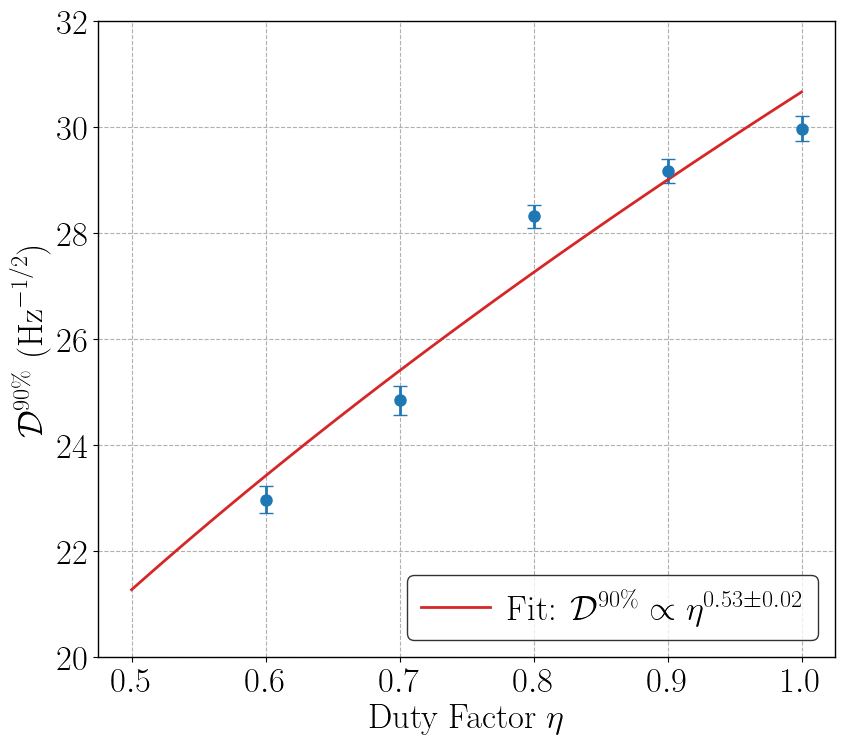

In [7]:
data = np.load(f'./result/data/D90_duty_factor_results_{f0}Hz.npz', allow_pickle=True)

D90 = []
D90_err = []
duty_factors = [1.0, 0.9, 0.8, 0.7, 0.6]

for duty_factor in duty_factors:
    pdet = data[f'pdet_df{duty_factor}']
    depth = data[f'depth_df{duty_factor}']
    
    print(pdet)
    print(depth)
    
    pdet = np.array(pdet)
    depth = np.array(depth)
    dpdet = binomialError(pdet, 1000)

    # Compute interpolation and error
    x, x_error = interpolation_error(0.9, depth, pdet, dpdet)
    if duty_factor == 1:
        D90.append(29.97)
        D90_err.append(0.24)

    else:
        D90.append(x)
        D90_err.append(x_error)
    
#D90[0] = 31.04
D90 = np.array(D90)[::-1]
D90_err = np.array(D90_err)[::-1]


duty_factors = np.array(duty_factors)[::-1]

# Define the power law function
from scipy.optimize import curve_fit
def power_law(x, k, a):
    return k * (x ** a)

# Normalize tobs
# Fit the power law with errors
popt, pcov = curve_fit(power_law, duty_factors, D90, p0=[1.3, 0.1], sigma=D90_err, absolute_sigma=True)
k, a = popt
k_err, a_err = np.sqrt(np.diag(pcov))

# Plot
fig, ax = plt.subplots(figsize=(9, 8))


ax.errorbar(duty_factors, D90, yerr=D90_err, fmt='o', color='tab:blue', 
            linewidth=2, markersize=8, capsize=5)

# Generate fitted curve
duty_factor_fit = np.linspace(0.5, 1, 100)
depth_fit = power_law(duty_factor_fit, k, a)
ax.plot(duty_factor_fit, depth_fit, linestyle='-', color='tab:red', 
        linewidth=2, label=f'Fit: $\\mathcal{{D}}^{{90\\%}} \\propto \eta^{{{a:.2f} \\pm {a_err:.2f}}}$')
# Axis labels and styling
ax.set_xlabel(r'$\mathrm{Duty\;Factor} \; \eta$')
ax.set_ylabel(r'$\mathcal{D}^{90\%}\; (\mathrm{Hz}^{-1/2})$')
#ax.set_xticks([5, 10, 15, 20])  # Ticks at 5, 10, 15, 20 days

ax.legend(loc=4, markerscale=2, handlelength=2, handletextpad=0.5, edgecolor='k')
ax.grid(True, which='major', linestyle='dashed')
ax.set_ylim(20, 32)

# Save figure
plt.tight_layout()
fig.savefig(f'./result/plots/{f0}Hz_depth_vs_dutyfactor.pdf', dpi=300, bbox_inches='tight')

# Generalization to $T_\mathrm{obs}$

In [2]:
tobs = [32, 64, 96, 128]
train_level_level = [32, 32, 32, 40]
time_list = [5, 10, 16, 21]

# Compute depth at 90% detection for each Tobs
results = {}
depth_values = []
for t, train_level, time in zip(tobs, train_level_level, time_list):

    if t == 32:
        Sn_values = np.linspace(23, 27, 5)  # Range of Sn values
    if t== 64:
        Sn_values = np.linspace(29, 33, 5)  # Range of Sn values
    if t== 96:
        Sn_values = np.linspace(33, 37, 5)  # Range of Sn values
    if t== 128:
        Sn_values = np.linspace(34, 38, 5)  # Range of Sn values

    size = (512, t)
    # Initialize model and load weights
    model = Attention_UNet(in_channels=4, out_channels=4, latent_channels=64, dropout_prob=0).to(device)
    version = f'H1L1_a1b1_20Hz_D{train_level}-{train_level}_T{time}_f512xTsft14400_ndata7000_noise7000_latent64_batch8_lr0.0001_512x{t}_MSELoss_dropout0'
    try:
        model.load_state_dict(torch.load(f"../trained_model/20Hz/best_pdet_model_mean_sq_{version}.pth", weights_only=False))
    except FileNotFoundError:
        print(f"Warning: Model file for Tobs={t} not found. Setting depth to NaN.")
        depth_values.append(np.nan)
        continue
    model.eval()

    # Load validation data
    filename = f'/scratch/kriles_root/kriles0/damoncht/unet_f/data/validation/{f0}Hz_H1L1_{size[0]}x{t}_{Tsft}s_4c_traindata_n1000_idx4.npz'
    try:
        targets = np.load(filename, allow_pickle=True)['clean_image']
    except FileNotFoundError:
        print(f"Warning: Validation data for Tobs={t} not found. Setting depth to NaN.")
        depth_values.append(np.nan)
        continue

    # Compute x_pfa from pure noise once
    noise = np.empty((1000,) + size + (4,))
    for i in range(noise.shape[0]):
        noise[i] = simNoise(sqrtSn=1, Tsft=Tsft, size=size, ndet=2, norm=False)
    noise = normalize(noise)
    noise_loader = load_dataset(noise, batch_size=8, shuffle=False)
    noise_stats = []
    with torch.no_grad():
        for images, in tqdm(noise_loader, desc=f"Computing x_pfa for Tobs={t}"):
            images = images.to(device)
            outputs = model(images)
            stats = compute_detection_statistic(outputs.cpu().numpy(), method='mean_sq')
            noise_stats.append(stats)
    noise_stats = np.concatenate(noise_stats)
    x_pfa = np.percentile(noise_stats, (1 - 0.71 / 100) * 100)

    # Compute pdet for each Sn
    pdet_per_sn = []
    for Sn in Sn_values:
        # Generate signal data
        noise = np.empty((targets.shape[0],) + size + (4,))
        for i in range(noise.shape[0]):
            noise[i] = simNoise(sqrtSn=Sn, Tsft=Tsft, size=size, ndet=2, norm=False)
        data = normalize(noise + targets)
        data_loader = load_dataset(data, batch_size=8, shuffle=False)

        # Compute detection statistics
        stats = []
        with torch.no_grad():
            for images, in tqdm(data_loader, desc=f'Evaluating Tobs={t}, Sn={Sn:.2f}'):
                images = images.to(device)
                outputs = model(images)
                batch_stats = compute_detection_statistic(outputs.cpu().numpy(), method='mean_sq')
                stats.append(batch_stats)
        stats = np.concatenate(stats)

        # Compute pdet
        mask = stats > x_pfa
        pdet = mask.sum() / stats.size
        pdet_per_sn.append(pdet)
    
    
    result_dict = {'pdet_per_sn': pdet_per_sn, 'Sn_values': Sn_values.tolist()}
    try:
        # Sort by pdet to ensure monotonicity for interpolation
        sort_idx = np.argsort(pdet_per_sn)[::-1]  # Descending order
        pdet_sorted = np.array(pdet_per_sn)[sort_idx]
        sn_sorted = Sn_values[sort_idx]
        # Check if pdet=0.9 is within the range of pdet_sorted
        if pdet_sorted.min() > 0.9 or pdet_sorted.max() < 0.9:
            raise ValueError("pdet=0.9 is outside the range of pdet values")
        result_dict['pdet_sorted'] = pdet_sorted.tolist()
        result_dict['sn_sorted'] = sn_sorted.tolist()
    except ValueError as e:
        print(f"Warning: Interpolation failed for Tobs={t} ({e}). Setting depth to NaN.")
        depth_values.append(np.nan)
        result_dict['pdet_sorted'] = []
        result_dict['sn_sorted'] = []
    results[f'Tobs_{t}'] = result_dict
# Save all numbers to a .npz file
np.savez(f'./result/data/depth_vs_tobs_results_{f0}Hz.npz', **results)

Evaluating Tobs=128, Sn=38.00: 100%|██████████| 125/125 [00:10<00:00, 12.42it/s]


[0.94  0.902 0.879 0.845 0.82 ] [23. 24. 25. 26. 27.]
[0.935 0.925 0.883 0.877 0.865] [29. 30. 31. 32. 33.]
[0.909 0.882 0.865 0.856 0.838] [33. 34. 35. 36. 37.]
[0.929 0.919 0.897 0.867 0.853] [34. 35. 36. 37. 38.]


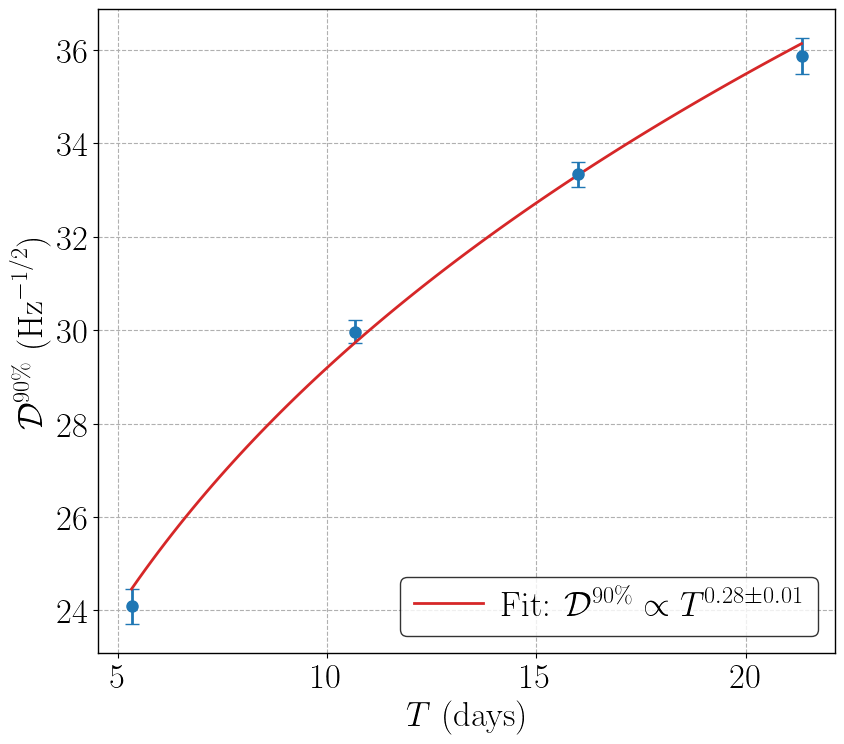

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.mlab as mlab
from matplotlib.ticker import MultipleLocator
import matplotlib.colors as colors
from scipy import stats
from PIL import Image
import numpy as np
from scipy.optimize import curve_fit
import warnings

# Matplotlib configuration
plt.rcParams.update({
    'text.usetex': True,
    'axes.linewidth': 1,
    'axes.grid': False,
    'axes.labelweight': 'normal',
    'font.family': 'DejaVu Sans',
    'font.size': 25,
    'mathtext.fontset': 'cm'
})

import matplotlib.pyplot as plt
f0 = 20
data = np.load(f'../result/data/depth_vs_tobs_results_{f0}Hz.npz', allow_pickle=True)

def binomialError(y, n):
    err =  np.sqrt(y*(1.-y)/n)
    err[err==0] = 1./n
    return err

# Linear interpolation for decreasing y
def interpolate_x(y_target, x, y):
    return np.interp(y_target, y[::-1], x[::-1])

# Estimate second derivative locally
def estimate_second_derivative(x, y, idx):
    h = np.diff(x)
    h_avg = np.mean(h) if not np.allclose(h, h[0]) else h[0]
    # Use points around the interpolation interval (idx-1, idx)
    if idx >= 1 and idx < len(y) - 1:
        # Central difference at x[idx-1] or x[idx]
        deriv2 = (y[idx+1] - 2*y[idx] + y[idx-1]) / (h_avg**2)
        return abs(deriv2)
    elif idx == 0 and len(y) >= 3:
        # Forward difference at x[0]
        deriv2 = (y[2] - 2*y[1] + y[0]) / (h_avg**2)
        return abs(deriv2)
    elif idx == len(y) - 1 and len(y) >= 3:
        # Backward difference at x[-1]
        deriv2 = (y[-1] - 2*y[-2] + y[-3]) / (h_avg**2)
        return abs(deriv2)
    return 1.0  # Fallback if insufficient points

# Error estimation
def interpolation_error(y_target, x, y, dy):
    idx = np.searchsorted(y[::-1], y_target, side='right')
    if idx == 0 or idx == len(y):
        raise ValueError("y_target is outside the range of y-values")
    # Adjust indices for decreasing y
    idx = len(y) - idx  # Convert to original array index
    x0, x1 = x[idx-1], x[idx]
    y0, y1 = y[idx-1], y[idx]
    dy0, dy1 = dy[idx-1], dy[idx]
    h = x1 - x0
    
    # Interpolated x
    x_interp = np.interp(y_target, y[::-1], x[::-1])
    
    # Interpolation error
    second_derivative = estimate_second_derivative(x, y, idx)
    y_interp_error = (1/8) * h**2 * second_derivative
    
    # Slope of the interpolated line
    slope = (y1 - y0) / (x1 - x0)
    
    # Propagate dy uncertainty to x
    t = (y_target - y0) / (y1 - y0)
    y_uncertainty = np.sqrt((1-t)**2 * dy0**2 + t**2 * dy1**2)
    
    # Total x-error
    x_error = np.sqrt((y_interp_error / abs(slope))**2 + (y_uncertainty / abs(slope))**2)
    
    return x_interp, x_error

tobs = [32, 64, 96, 128]
D90 = []
D90_err = []
for t in tobs:
    pdet = data[f'Tobs_{t}'].item()['pdet_per_sn']
    depth = data[f'Tobs_{t}'].item()['Sn_values']

    pdet = np.array(pdet)
    depth = np.array(depth)
    dpdet = binomialError(pdet, 1000)
    print(pdet, depth)
    # Compute interpolation and error
    x, x_error = interpolation_error(0.9, depth, pdet, dpdet)
    
    if t == 64:
        D90.append(29.97)
        D90_err.append(0.24)
    else:
        D90.append(x)
        D90_err.append(x_error)


D90 = np.array(D90)
D90_err = np.array(D90_err)

# Define the power law function
from scipy.optimize import curve_fit
def power_law(tobs_normalized, k, a):
    return k * (tobs_normalized ** a)

# Normalize tobs
tobs = np.array(tobs) 

# Fit the power law with errors
popt, pcov = curve_fit(power_law, tobs/6, D90, p0=[1.3, 0.1], sigma=D90_err, absolute_sigma=True)
k, a = popt
k_err, a_err = np.sqrt(np.diag(pcov))

# Plot
fig, ax = plt.subplots(figsize=(9, 8))


ax.errorbar(tobs/6, D90, yerr=D90_err, fmt='o', color='tab:blue', 
            linewidth=2, markersize=8, capsize=5)

# Generate fitted curve
tobs_fit = np.linspace(32, 128, 100)
depth_fit = power_law(tobs_fit/6, k, a)
ax.plot(tobs_fit/6, depth_fit, linestyle='-', color='tab:red', 
        linewidth=2, label=f'Fit: $\\mathcal{{D}}^{{90\\%}} \\propto T^{{{a:.2f} \\pm {a_err:.2f}}}$')
# Axis labels and styling
ax.set_xlabel(r'$T$ (days)')
ax.set_ylabel(r'$\mathcal{D}^{90\%}\; (\mathrm{Hz}^{-1/2})$')
#ax.set_xticks([5, 10, 15, 20])  # Ticks at 5, 10, 15, 20 days

ax.legend(loc=4, markerscale=2, handlelength=2, handletextpad=0.5, edgecolor='k')
ax.grid(True, which='major', linestyle='dashed')
#ax.set_ylim(20, 40)

# Save figure
plt.tight_layout()
plt.savefig(f'../result/plots/{f0}Hz_depth_vs_tobs.pdf', dpi=300, bbox_inches='tight')